# KMeans Clustering Project

What if your data already contains hidden patterns... but nobody labeled them for you?

That is the doorway into clustering.

In supervised learning, someone tells the model the answer. Churned or stayed. Fraud or not fraud. Price or demand. But in unsupervised learning, the model walks into a room full of unlabeled examples and tries to organize the chaos.

This project is about teaching a machine to discover hidden groups in messy real-world data.

> Watching KMeans is like watching structure emerge from fog.

## 1. Problem Statement

Businesses want segmentation because not every customer behaves the same way.

Some customers have high income and spend freely. Some have high income but spend cautiously. Some have lower income but respond strongly to promotions. Some behave like everyday steady shoppers.

The problem is that nobody hands us a perfect label saying "premium segment" or "budget enthusiast." We often have behavior, not categories.

Clustering helps us ask:

> Can the data reveal customer groups before we name them?

This matters in personalized marketing, recommendation systems, store strategy, fraud pattern discovery, healthcare grouping, and customer experience design.

## 2. What Is Clustering?

Clustering is the art of grouping similar data points together.

Imagine walking into a library where every book has been dumped onto the floor. Nobody labeled the shelves. You start noticing patterns: cookbooks together, novels together, textbooks together, travel guides together.

That is clustering.

Or imagine a party. Nobody assigned groups, but people naturally gather by shared interests, conversation style, and energy. The room organizes itself.

In machine learning, clustering asks a machine to do something similar. It looks at features and says:

> These points are close to each other. Maybe they belong together.

This is unsupervised learning because there is no target label. The model is not predicting a known answer. It is discovering structure.

## 3. Why KMeans?

KMeans is popular because it is simple, fast, and interpretable.

The core idea:

1. Choose K, the number of clusters.
2. Place K centroids in the data space.
3. Assign each point to the nearest centroid.
4. Move each centroid to the center of its assigned points.
5. Repeat until the centroids stop moving much.

A centroid is like a temporary magnet. Points gather around the closest magnet. Then the magnet moves toward the center of the points it attracted.

Over time, the magnets settle into the hidden structure of the data.

## 4. Dataset Overview

Dataset: Mall Customers segmentation dataset from a public GitHub gist.

Rows: 200 customers

Features:

- `customer_id`: customer identifier
- `gender`: customer gender
- `age`: customer age
- `annual_income`: annual income in thousands
- `spending_score`: mall-assigned spending behavior score from 1 to 100

Business interpretation:

The goal is to discover customer segments based on demographics and shopping behavior. The most visually important segmentation uses annual income and spending score.

## 5. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from src.preprocessing.data_preprocessing import FEATURE_COLUMNS, SEGMENT_FEATURES, save_processed, scale_features
from src.clustering.kmeans_utils import assign_segment_names, cluster_summary, fit_kmeans
from src.evaluation.cluster_metrics import evaluate_k_range
from src.dimensionality_reduction.pca_utils import run_pca
from src.experiments.centroid_steps import centroid_snapshots
from src.visualization.plots import plot_clusters, plot_elbow, plot_pca_clusters, plot_silhouette

sns.set_theme(style="whitegrid", palette="Set2")
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

## 6. Load Dataset

In [2]:
raw_path = PROJECT_ROOT / "data/raw/mall_customers.csv"
processed_path = PROJECT_ROOT / "data/processed/mall_customers_processed.csv"

df = save_processed(raw_path, processed_path)
df.head()

,customer_id,gender,age,annual_income,spending_score
0,0001,Male,19,15,39
1,0002,Male,21,15,81
2,0003,Female,20,16,6
3,0004,Female,23,16,77
4,0005,Female,31,17,40


## 7. Initial Data Inspection

Before clustering, we inspect the space the model will explore. KMeans is distance-based, so missing values, scale, and feature ranges matter.

In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nFeature summary:")
df[FEATURE_COLUMNS].describe().T

Shape: (200, 5)

Missing values:
customer_id       0
gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

Feature summary:


,count,mean,std,min,25%,50%,75%,max
age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
annual_income,200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
spending_score,200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     200 non-null    object
 1   gender          200 non-null    object
 2   age             200 non-null    int64 
 3   annual_income   200 non-null    int64 
 4   spending_score  200 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 7.9+ KB


## 8. Exploratory Data Analysis

Clustering starts before the algorithm. We first look for hints: income patterns, spending patterns, age behavior, and relationships between features.

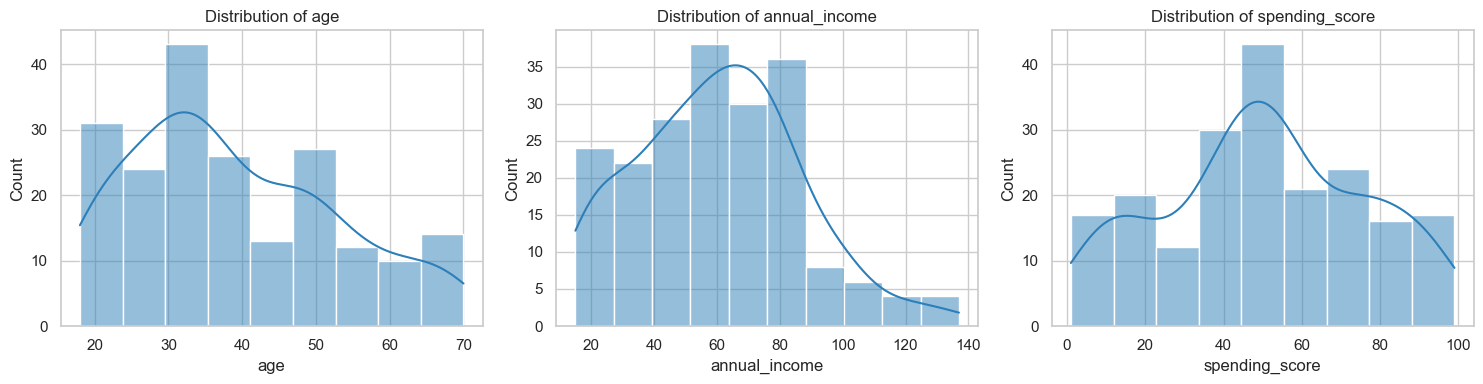

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, FEATURE_COLUMNS):
    sns.histplot(df[col], kde=True, ax=ax, color="#2c7fb8")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

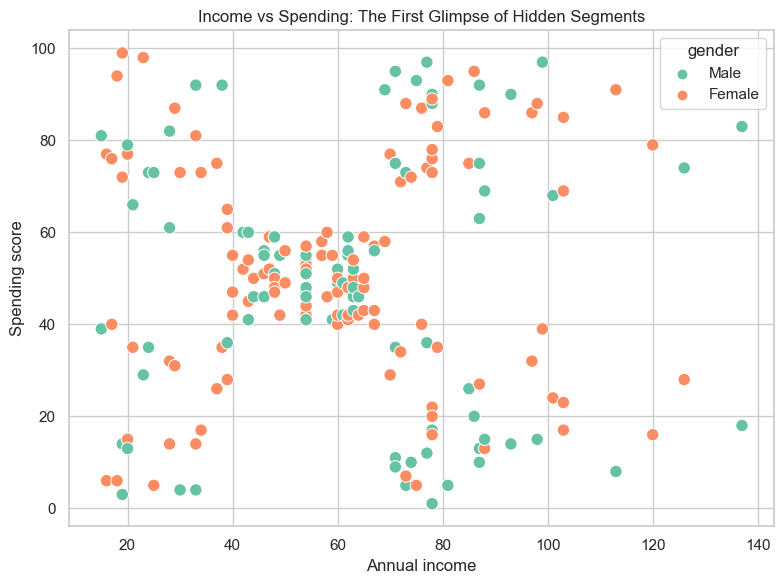

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="annual_income", y="spending_score", hue="gender", s=80, edgecolor="white")
plt.title("Income vs Spending: The First Glimpse of Hidden Segments")
plt.xlabel("Annual income")
plt.ylabel("Spending score")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "income_spending_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

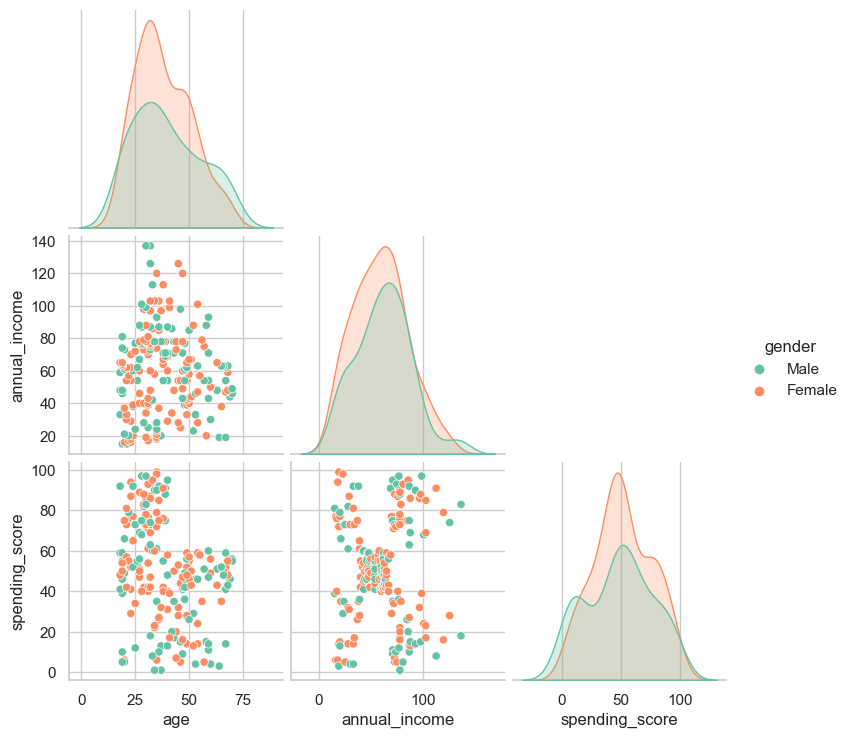

In [7]:
sns.pairplot(df[FEATURE_COLUMNS + ["gender"]], hue="gender", corner=True)
plt.savefig(IMAGES_DIR / "pairplot.png", dpi=160, bbox_inches="tight")
plt.show()

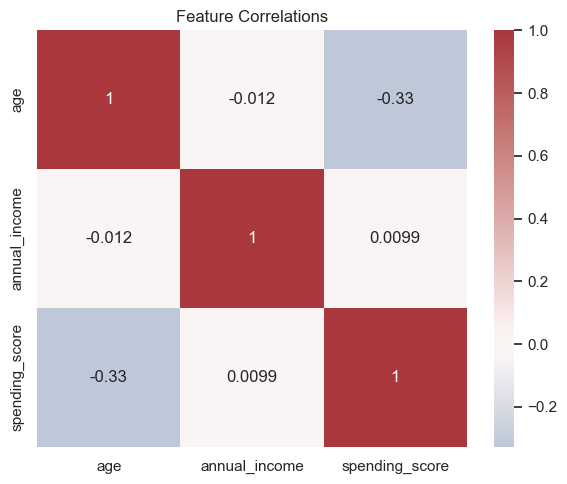

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[FEATURE_COLUMNS].corr(), annot=True, cmap="vlag", center=0)
plt.title("Feature Correlations")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "correlations.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Why Feature Scaling Matters

KMeans uses distance.

That means feature scale matters deeply. A feature measured in thousands can dominate a feature measured from 1 to 100. The model does not know which unit is meaningful. It only sees distance.

Scaling puts features on a comparable scale so the model does not confuse measurement units with importance.

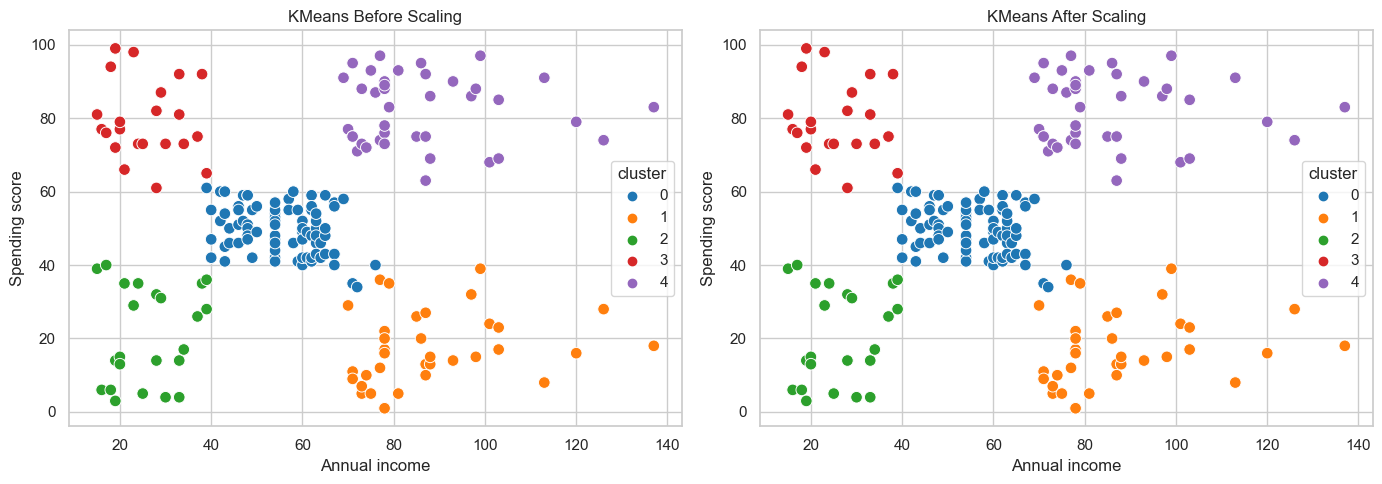

In [9]:
segment_df = df[SEGMENT_FEATURES].copy()
scaled_segment_df, segment_scaler = scale_features(df, SEGMENT_FEATURES)

raw_model, raw_labels = fit_kmeans(segment_df, n_clusters=5)
scaled_model, scaled_labels = fit_kmeans(scaled_segment_df, n_clusters=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.assign(cluster=raw_labels), x="annual_income", y="spending_score", hue="cluster", palette="tab10", ax=axes[0], s=70)
axes[0].set_title("KMeans Before Scaling")
sns.scatterplot(data=df.assign(cluster=scaled_labels), x="annual_income", y="spending_score", hue="cluster", palette="tab10", ax=axes[1], s=70)
axes[1].set_title("KMeans After Scaling")
for ax in axes:
    ax.set_xlabel("Annual income")
    ax.set_ylabel("Spending score")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "scaling_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Understanding KMeans Intuitively

KMeans feels almost alive because it repeats a simple loop.

First, centroids are placed. At the beginning, they may be awkward guesses.

Then every customer asks: which centroid am I closest to?

The customers gather around their nearest centroid. Then each centroid moves to the average location of the customers assigned to it.

Assign. Move. Assign. Move.

The movement slows down. The groups stabilize. Structure emerges.

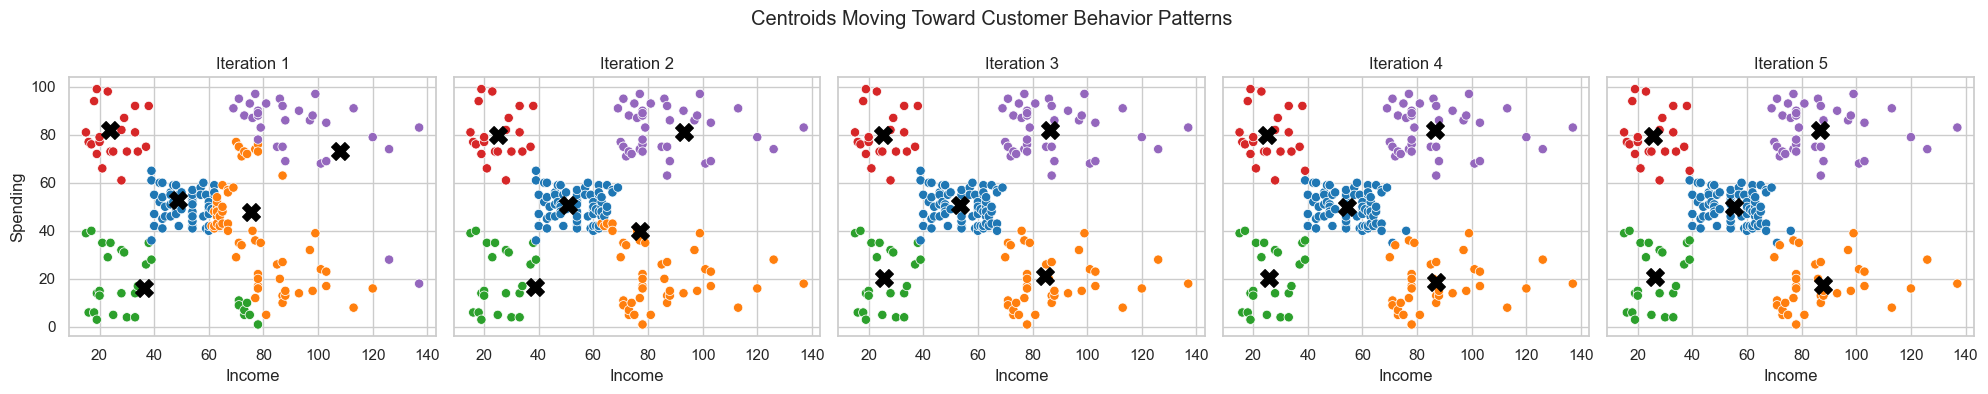

In [10]:
snapshots = centroid_snapshots(scaled_segment_df.values, n_clusters=5, max_steps=5, random_state=7)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
for ax, snapshot in zip(axes, snapshots):
    labels = snapshot["labels"]
    centers_original = segment_scaler.inverse_transform(snapshot["centers"])
    sns.scatterplot(x=df["annual_income"], y=df["spending_score"], hue=labels, palette="tab10", ax=ax, s=45, legend=False)
    ax.scatter(centers_original[:, 0], centers_original[:, 1], c="black", marker="X", s=160)
    ax.set_title(f"Iteration {snapshot['step']}")
    ax.set_xlabel("Income")
axes[0].set_ylabel("Spending")
plt.suptitle("Centroids Moving Toward Customer Behavior Patterns")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "centroid_movement.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Choosing the Number of Clusters (K)

Choosing K matters because it changes the story we tell about customers.

Too few clusters compress different behaviors together. Too many clusters slice the audience into tiny groups that may not be useful.

We use two tools:

- Elbow method: watches inertia fall as K increases
- Silhouette score: asks whether clusters are cohesive and separated

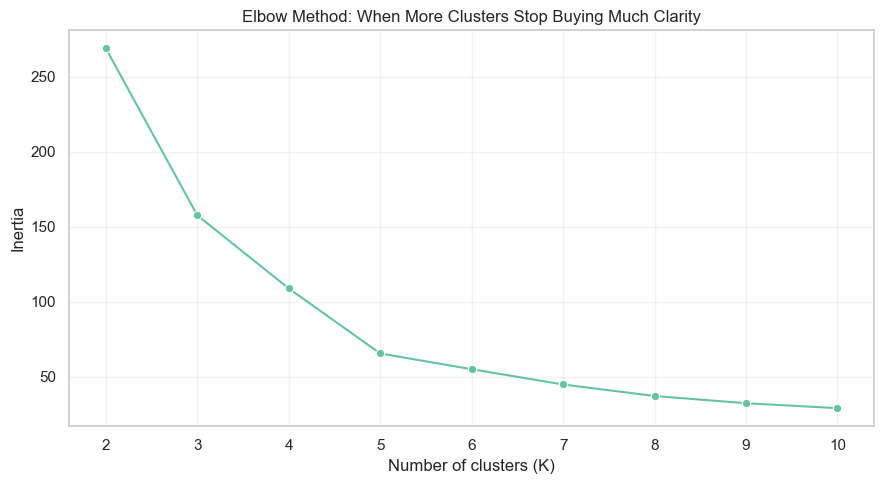

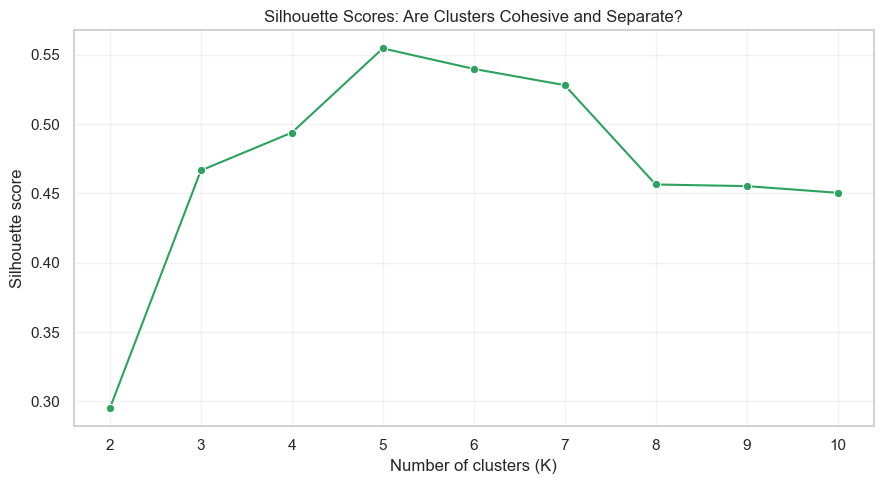

,k,inertia,silhouette_score
0,2,269.0168,0.2951
1,3,157.7040,0.4666
2,4,108.9213,0.4939
3,5,65.5684,0.5547
4,6,55.0573,0.5399
5,7,44.8648,0.5281
6,8,37.1829,0.4565
7,9,32.3753,0.4553
8,10,29.0612,0.4505


In [11]:
k_results = evaluate_k_range(scaled_segment_df, k_values=range(2, 11))
plot_elbow(k_results, IMAGES_DIR / "elbow_method.png")
plt.show()
plot_silhouette(k_results, IMAGES_DIR / "silhouette_scores.png")
plt.show()
k_results.round(4)

## 12. Building the Final KMeans Model

The classic mall customer segmentation pattern is strongest at K=5 using income and spending score. It produces business-friendly groups that are easy to interpret.

In [12]:
chosen_k = 5
final_model, final_labels = fit_kmeans(scaled_segment_df, n_clusters=chosen_k, random_state=42, n_init=20)
df_clustered = df.copy()
df_clustered["cluster"] = final_labels
print("Chosen K:", chosen_k)
print("Silhouette score:", round(silhouette_score(scaled_segment_df, final_labels), 4))
df_clustered.head()

Chosen K: 5
Silhouette score: 0.5547


,customer_id,gender,age,annual_income,spending_score,cluster
0,0001,Male,19,15,39,2
1,0002,Male,21,15,81,3
2,0003,Female,20,16,6,2
3,0004,Female,23,16,77,3
4,0005,Female,31,17,40,2


## 13. Visualizing Clusters

This is the moment clustering becomes visible.

The model was never told what a segment is. It only saw customer behavior. Yet the structure appears: high-income high-spending customers, high-income cautious spenders, lower-income enthusiastic shoppers, careful shoppers, and balanced everyday customers.

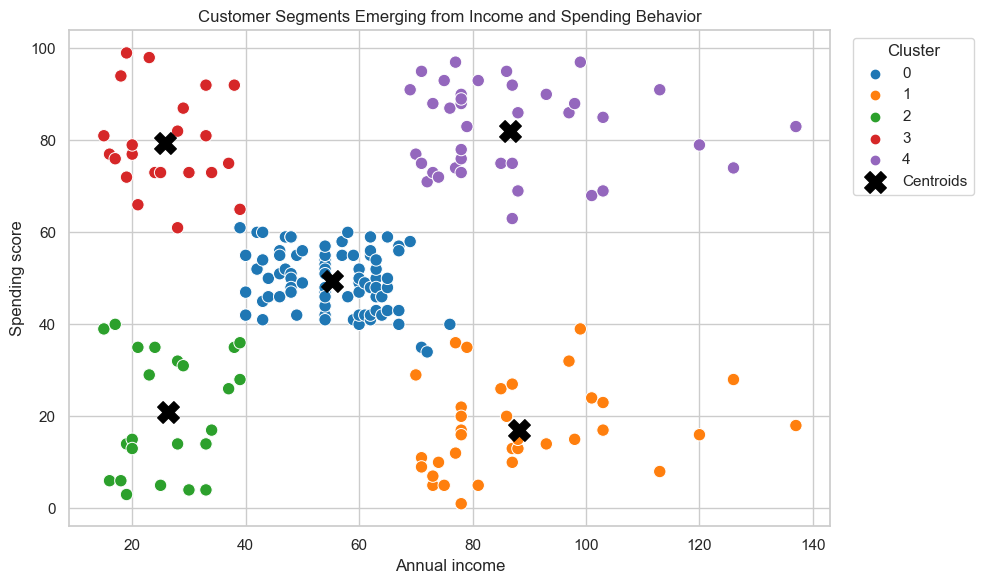

In [13]:
centers_original = segment_scaler.inverse_transform(final_model.cluster_centers_)
plot_clusters(df, final_labels, IMAGES_DIR / "cluster_visualization.png", centers=centers_original)
plt.show()

## 14. Understanding Cluster Profiles

Clustering is not finished when labels are assigned.

The real work begins when we interpret the clusters. A cluster label like `2` means nothing by itself. We translate it into a customer story.

In [14]:
summary = cluster_summary(df_clustered, final_labels, FEATURE_COLUMNS)
summary = assign_segment_names(summary)
summary

,cluster,age,annual_income,spending_score,customers,segment_name
0,0,42.72,55.30,49.52,81,Balanced everyday customers
1,1,41.11,88.20,17.11,35,High-income cautious spenders
2,2,45.22,26.30,20.91,23,Low-income careful shoppers
3,3,25.27,25.73,79.36,22,Budget enthusiastic shoppers
4,4,32.69,86.54,82.13,39,Premium high-value customers


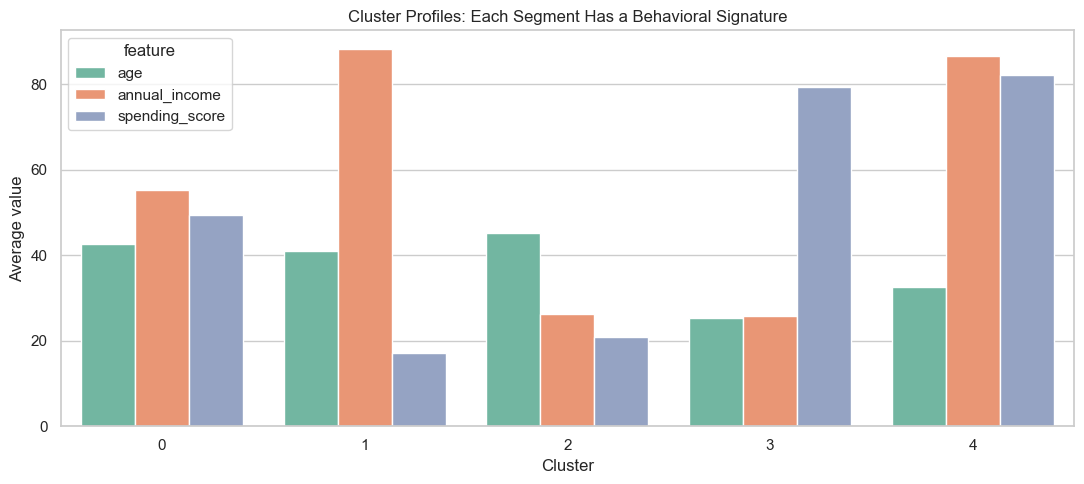

In [15]:
plt.figure(figsize=(11, 5))
profile_plot = summary.melt(id_vars=["cluster", "segment_name", "customers"], value_vars=FEATURE_COLUMNS, var_name="feature", value_name="average")
sns.barplot(data=profile_plot, x="cluster", y="average", hue="feature")
plt.title("Cluster Profiles: Each Segment Has a Behavioral Signature")
plt.xlabel("Cluster")
plt.ylabel("Average value")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "cluster_profiles.png", dpi=160, bbox_inches="tight")
plt.show()

## 15. Cluster Evaluation

Clustering evaluation is tricky because there is no true label.

Silhouette score helps by measuring two things:

- cohesion: are points close to their own cluster?
- separation: are points far from other clusters?

But the best cluster solution is not always the highest score. Business interpretability matters too.

In [16]:
print("Final inertia:", round(final_model.inertia_, 2))
print("Final silhouette score:", round(silhouette_score(scaled_segment_df, final_labels), 4))

Final inertia: 65.57
Final silhouette score: 0.5547


## 16. Dimensionality Reduction for Visualization

PCA compresses multiple features into fewer dimensions while preserving as much variation as possible.

It is not magic. It is a way to create a useful map. If the original data has three or thirty dimensions, PCA can help us draw a two-dimensional picture of the cluster structure.

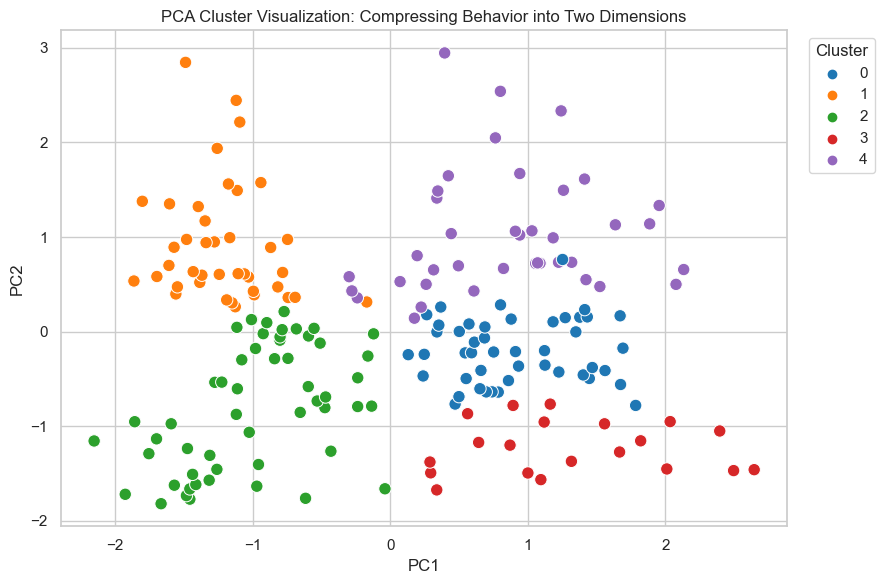

Explained variance by PC1 and PC2: [0.4427 0.3331]


In [17]:
scaled_all_df, all_scaler = scale_features(df, FEATURE_COLUMNS)
all_model, all_labels = fit_kmeans(scaled_all_df, n_clusters=5)
pca_df, pca = run_pca(scaled_all_df, n_components=2)
plot_pca_clusters(pca_df, all_labels, IMAGES_DIR / "pca_clusters.png")
plt.show()
print("Explained variance by PC1 and PC2:", np.round(pca.explained_variance_ratio_, 4))

## 17. Limitations of KMeans

KMeans is powerful, but it has assumptions.

It is sensitive to scaling. It can be sensitive to initialization. It works best with roughly round, compact clusters. It can be pulled by outliers. It requires us to choose K. It does not naturally handle categorical variables without preprocessing.

Most importantly, clusters are not truth. They are useful patterns that need human interpretation.

## 18. Real-World Applications

Clustering appears anywhere we need to discover groups without labels:

- marketing segmentation
- recommendation systems
- anomaly detection
- social media communities
- healthcare patient groups
- finance customer profiles
- product usage patterns

It helps teams move from one-size-fits-all decisions to segment-aware strategy.

## 19. Final Takeaway

KMeans does not know what a customer is.

It does not know what marketing means.

It only knows distance, similarity, and repeated adjustment. Yet from those simple ingredients, meaningful segments can emerge.

That is the quiet power of unsupervised learning: finding structure before anyone names it.

## 20. Interview Questions

For detailed interview preparation, see:

`kmeans-clustering/interview_questions.md`

The companion interview article explains these concepts in practical ML engineering language.